# No Regularization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
data = np.loadtxt('data/logistic_regression_data.csv', delimiter=',', dtype=np.float64)
X, y = data[:, :-1], data[:, -1].reshape((-1, 1))   # In data, first 2 cols are coordinates, last col is label (0 or 1). Points are distributed in a circular manner, where inner clircle is labeled 0 and outer circle is labeled 1.

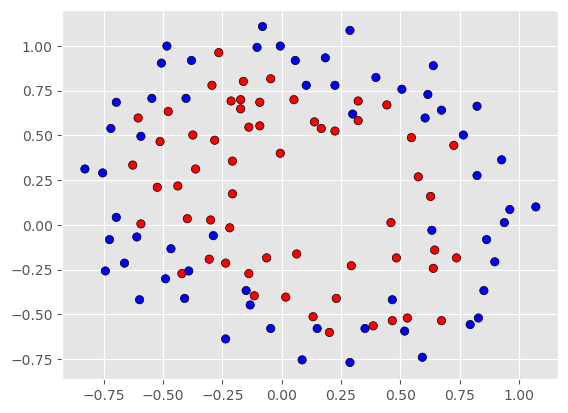

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
def loss(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    cos = -(np.sum(y * np.log(h)) + np.sum((1 - y) * np.log(1 - h))) / len(y)
    return cos

In [6]:
def gradient(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    grad = np.dot(X.T, (h - y)) / len(y)
    return grad

#### The Featurization Trick

In [7]:
def expand_feature(x1, x2, power = 2):
    # Expand a 2D feature matrix to polynomial features up to the power
    new_X = np.ones((x1.shape[0], 1))   # Add a column of ones for bias term
    for i in range(1, power + 1):
        for j in range(i + 1):
            new_feature = (x1 ** (i - j)) * (x2 ** j)
            new_X = np.hstack((new_X, new_feature.reshape((-1, 1))))    # np.append(new_X, (x1**(i-j)*(x2**j)).reshape((-1,1)), axis=1)
    return new_X

In [8]:
def predict(theta, X):
    prob = sigmoid(np.dot(X, theta))
    return (prob >= 0.5).astype(int).flatten()

In [9]:
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    costs = []
    for _ in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta -= (alpha / m) * np.dot(X.T, (h - y))
        costs.append(loss(theta, X, y))
    return theta, costs

In [10]:
# Implement Logistic Regression without Regularization
def logistic_regression_no_reg(X, y, power=2, alpha=0.01, num_iters=100):   # 3 hyper params: Learning rate APLHA, num of iterations, power of polynomial features
    X_expanded = expand_feature(X[:, 0], X[:, 1], power = power) # Expand features to given power
    initial_theta = np.zeros((X_expanded.shape[1], 1))  # Initialize theta
    theta, costs = gradient_descent(X_expanded, y, initial_theta, alpha, num_iters)
    predicted = predict(theta, X_expanded)
    accuracy = np.mean(predicted == y.flatten()) * 100
    print(f'Accuracy without regularization: {accuracy:.2f}%')
    return predicted, theta, costs
    

#### Decide the polynomial power in the features, and the number of iterations

In [11]:
power, num_iters, alpha = 20, 20000, 0.6
predicted, theta, costs = logistic_regression_no_reg(X, y, power=power, alpha=alpha, num_iters=num_iters)

Accuracy without regularization: 85.59%


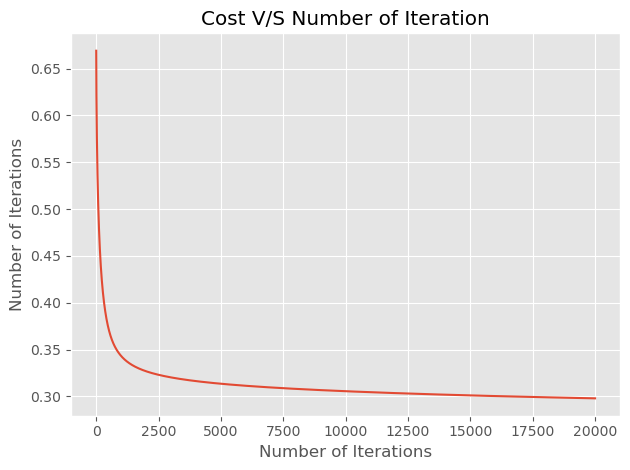

In [12]:
plt.plot(range(num_iters), costs)
plt.xlabel('Number of Iterations')
plt.ylabel('Number of Iterations')
plt.title('Cost V/S Number of Iteration')
plt.grid(True)
plt.tight_layout()

In [13]:
'The accuracy is {:.2f}%'.format(np.sum(predicted == y.flatten()) / len(y) * 100)

'The accuracy is 85.59%'

#### Visualize the classifier

/var/folders/_k/65fkzwqj0m57fvjr4r1gyj_80000gn/T/ipykernel_17873/208324689.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i, j] = np.dot(features, theta)


Text(0, 0.5, 'Feature 2 aka Y')

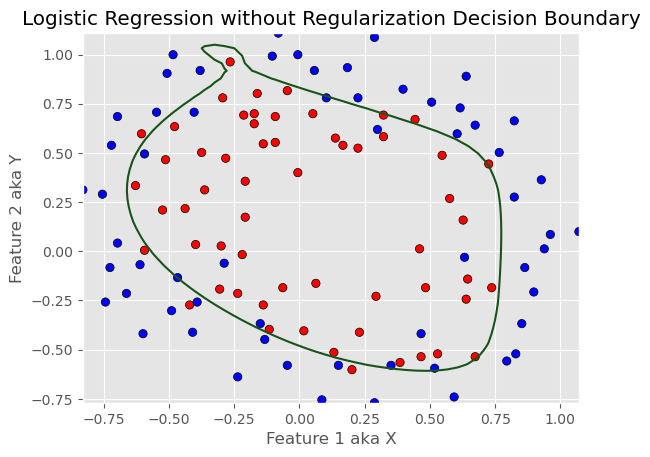

In [14]:
u = np.linspace(np.min(X[:, 0]), max(X[:, 0]), 50)
v = np.linspace(np.min(X[:, 1]), max(X[:, 1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        features = expand_feature(np.array([u[i]]).reshape(1, -1), np.array([v[j]]).reshape(1, -1), power=power)
        z[i, j] = np.dot(features, theta)
z = z.T

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.contour(u,v,z, [0], colors = ["#1A531AFF"])
plt.title('Logistic Regression without Regularization Decision Boundary')
plt.xlabel('Feature 1 aka X')
plt.ylabel('Feature 2 aka Y')

This is an example of Overfitted model. Try changing the order hyperparam and see that model is not getting overfitted. This will also compute optimal model in less time with same accuracy, making unnecessary increase in compute time in manifolds, and that too giving over-fitted model.

# With Regularization

It prevents coefficients to become too large ==> Prevents overfitting ==> prevent capturing noise in data ==> produces easy model that fits well with testing data as well.

Cost==> {-(1/m) * SUMMATION[y * log(sigmoid(H(x))) + (1-y)*(log(1-sigmoid(Hx)))]} + {(1/m) * lamda * theta_tild^2}    ===    loss + reg

Gradient ==> {(1/m) * (X.T * (sigmoid(H(x)) - y_cap))} + {(1/m) * 2 * lambda * theta_tild}  ;   where theta_tild is theta vector but the bias term will be set as zero.

Gradient updated ==> theta_(i+1) = theta_i - [alpha * (gradient)]

In [15]:
def cost_with_reg(theta, X, y, lambda_ = 0):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    theta1 = theta.copy()
    theta1[0] = 0  # Exclude bias term from regularization
    reg_term = (lambda_ / m) * np.sum(theta1 ** 2)  # Exclude bias term from regularization. ALSO, in another method, we divide by 2m instead of m. Since we are not using 2m, so we multiply by 2 in gradient calculation in grad_reg function below in the reg_term while calculating gradient.
    cost = -(np.sum(y * np.log(h)) + np.sum((1 - y) * np.log(1 - h))) / m + reg_term
    return cost

#### Regularization: Gradient

In [16]:
def grad_reg(theta, X, y, lambda_ = 0):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    theta1 = theta.copy()
    theta1[0] = 0  # Exclude bias term from regularization
    reg_term = (lambda_ / m) * theta1
    grad = (np.dot(X.T, (h - y)) / m) + (2 * reg_term)
    return grad

#### Regularization: Gradient Descent

In [17]:
def gradient_descent_reg(X, y, theta, alpha, num_iters = 100, lambda_ = 0):
    m = len(y)
    costs = []
    for _ in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta1 = theta.copy()
        theta1[0] = 0  # Exclude(or, replacing) bias term from regularization
        theta -= alpha * grad_reg(theta1, X, y, lambda_)
        costs.append(cost_with_reg(theta1, X, y, lambda_))
    return theta, costs

#### Regularization: Logistic Regression

In [18]:
def logistic_regression_with_reg(X, y, power=2, alpha=0.01, num_iters=100, lambda_ = 0):   # 4 hyper params: Learning rate APLHA, num of iterations, power of polynomial features, regularization parameter lambda
    X_expanded = expand_feature(X[:, 0], X[:, 1], power = power) # Expand features to given power
    initial_theta = np.zeros((X_expanded.shape[1], 1), dtype = np.float64)  # Initialize theta
    theta, costs = gradient_descent_reg(X_expanded, y, initial_theta, alpha, num_iters, lambda_)
    predicted = predict(theta, X_expanded)
    accuracy = np.mean(predicted == y.flatten()) * 100
    print(f'Accuracy with regularization: {accuracy:.2f}%')
    return predicted, theta, costs

#### Regularization: Decide the polynomial feature, number of iterations, lambda

In [19]:
power, num_iters, alpha, lambda_ = 7, 25, 0.5, 0.8
predicted, theta, costs = logistic_regression_with_reg(X, y, power=power, alpha=alpha, num_iters=num_iters, lambda_=lambda_)

Accuracy with regularization: 69.49%


In [20]:
'The accuracy is {:.2f}%'.format(np.sum(predicted == y.flatten()) / len(y) * 100)

'The accuracy is 69.49%'

#### Regularization: Visualize Results

/var/folders/_k/65fkzwqj0m57fvjr4r1gyj_80000gn/T/ipykernel_17873/2943271805.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i, j] = np.dot(features, theta)


Text(0, 0.5, 'Feature 2 aka Y')

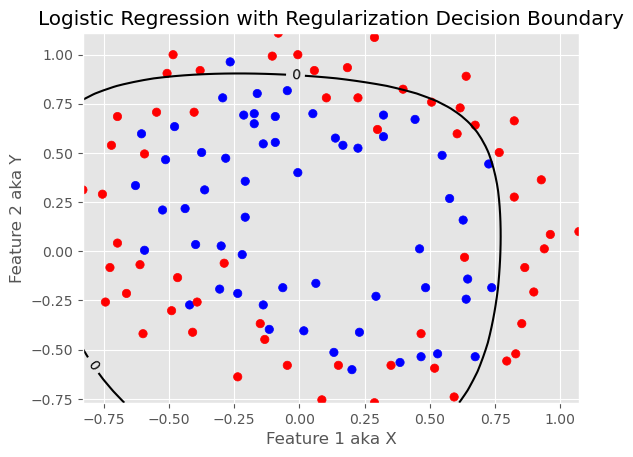

In [21]:
u = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 50)
v = np.linspace(np.min(X[:, 1]), np.max(X[:, 1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        features = expand_feature(np.array([u[i]]).reshape(1, -1), np.array([v[j]]).reshape(1, -1), power=power)
        z[i, j] = np.dot(features, theta)
z = z.T

plt.scatter(X[:, 0], X[:, 1], color=['blue' if label==1 else 'red' for label in y])
contour = plt.contour(u,v,z, [0], colors=['k'])
plt.clabel(contour)
plt.title('Logistic Regression with Regularization Decision Boundary')
plt.xlabel('Feature 1 aka X')
plt.ylabel('Feature 2 aka Y')

Play with different hyper parameters to observe the impact on accuracy and precision and model type(over|under-fitted)

## Multi-Class Logistic Regression == SoftMax Logistic Regression == Multinomial Logistic Regression

In [22]:
np.random.seed(None)

In [23]:
N = 100 # number of points per class
D = 2 # dimensionality, we use 2D data for easy visulization
K = 3 # number of classes, binary for logistic regression
X = np.zeros((N * K, D), dtype = float) # data matrix (each row = single example, can view as xy coordinates)
y_ = np.zeros(N * K, dtype = int) # class labels for plotting
y = np.zeros((N * K, K), dtype = int) # class labels for training


for i in range(K):
    r = np.random.normal(i + 0.5, 0.3, (N, 1)) # radius
    t = np.linspace(0, np.pi * 2, N).reshape(N, 1)  # theta
    
    X[i * N:(i + 1) * N] = np.append(r * np.sin(t), r * np.cos(t), axis = 1)
    y_[i * N:(i + 1) * N] = i
    y[i * N:(i + 1) * N, i] = 1

/var/folders/_k/65fkzwqj0m57fvjr4r1gyj_80000gn/T/ipykernel_17873/1049108228.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')


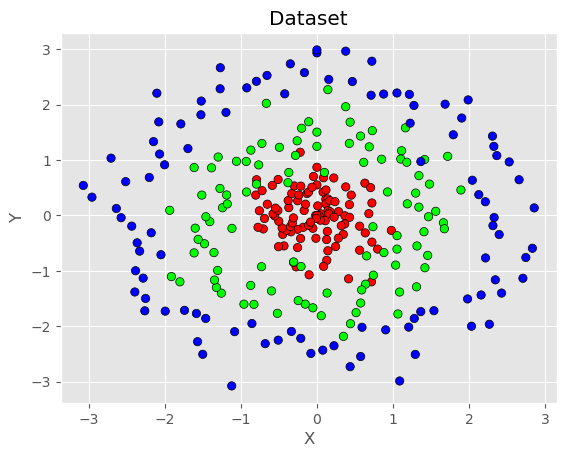

In [24]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [25]:
def predict_multi_class(theta, X):
    return np.argmax(sigmoid(np.dot(X, theta)), axis = 1)

In [26]:
def logistic_regression_reg_multi_class(X, y, power = 2, alpha = 0.01, lam = 20, num_iters = 2000):
    X = expand_feature(X[:, 0], X[:, 1], power = power)
    theta = np.zeros((X.shape[1], y.shape[1]), dtype = np.float64)
    theta, costs = gradient_descent_reg(X, y, theta, alpha, num_iters, lam)
    predicted = predict_multi_class(theta, X)
    return predicted, theta, costs

In [27]:
num_iters = 1000
predicted, theta, costs = logistic_regression_reg_multi_class(X, y, alpha = 0.3, lam = 0, num_iters = num_iters)
print('The accuracy is {:.2f} %'.format(sum(predicted == y_)/len(y_)*100))

The accuracy is 33.33 %


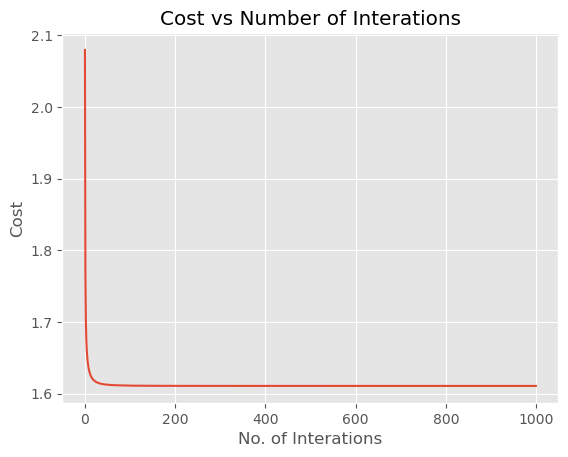

In [28]:
plt.plot(range(num_iters), costs)
plt.title('Cost vs Number of Interations')
plt.ylabel('Cost')
plt.xlabel('No. of Interations')
plt.show()

In [29]:
print('The accuracy is {:.2f} %'.format(sum(predicted == y_)/len(y_)*100))

The accuracy is 33.33 %


/var/folders/_k/65fkzwqj0m57fvjr4r1gyj_80000gn/T/ipykernel_17873/4021644751.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = np.dot(expand_feature(u[i].reshape(1,-1),v[j].reshape(1,-1)),theta[:, k])


/var/folders/_k/65fkzwqj0m57fvjr4r1gyj_80000gn/T/ipykernel_17873/4021644751.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')


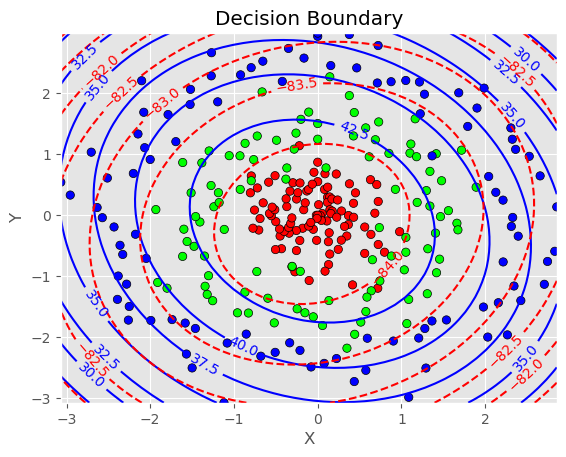

: 

In [ ]:
u = np.linspace(min(X[:, 0]),max(X[:, 0]), 50)  
v = np.linspace(min(X[:, 1]),max(X[:, 1]), 50)

for k in range(0, 3, 2):
    z = np.zeros((len(u),len(v)))
    for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = np.dot(expand_feature(u[i].reshape(1,-1),v[j].reshape(1,-1)),theta[:, k])   

    z = np.transpose(z)
    contour = plt.contour(u,v,z, colors=['blue' if k==0 else 'red'])
    plt.clabel(contour)
    
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title('Decision Boundary')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()